In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

### I. Load Iris dataset

In [59]:
data = datasets.load_iris()
X = data.data
y = data.target

print(data.DESCR)
print(X.shape)
print(y.shape)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### II. Hyperparameter tuning with cross_val_score (10-fold CV)
- use cv=10 directly (no custom KFold object).
- K range: 
    - First batch: 1 to 30
    - Second batch: 11 to 15

In [49]:
def cross_val_acc_graph(first, end):
    k_range = range(first, end)
    cv_means = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=10)
        cv_means.append(scores.mean())

    cv_means = np.array(cv_means)

    best_idx = int(np.argmax(cv_means))
    best_k_cv = list(k_range)[best_idx]
    print("Best k from cross_val_score(cv=10):", best_k_cv)
    print("Best mean CV accuracy:", cv_means[best_idx])

    # Plot: Value of K for KNN vs Cross-Validated Accuracy
    plt.figure()
    plt.plot(list(k_range), cv_means)
    plt.xlabel("Value of K for KNN")
    plt.ylabel("Cross-Validated Accuracy")
    plt.title("KNN on Iris: 10-fold Cross-Validated Accuracy vs K")
    plt.grid(True, alpha=0.3)
    plt.show()

Best k from cross_val_score(cv=10): 13
Best mean CV accuracy: 0.9800000000000001


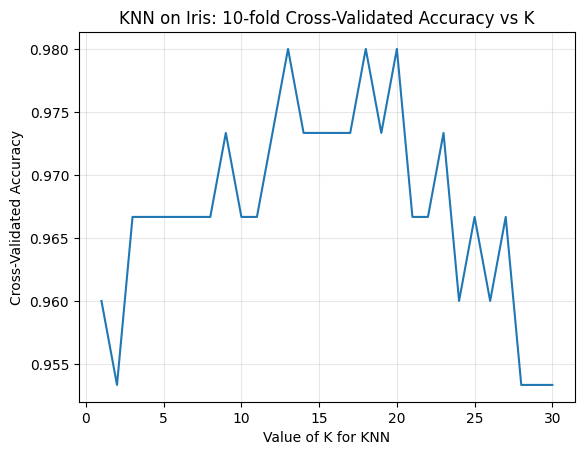

In [50]:
cross_val_acc_graph(1, 31)

Best k from cross_val_score(cv=10): 13
Best mean CV accuracy: 0.9800000000000001


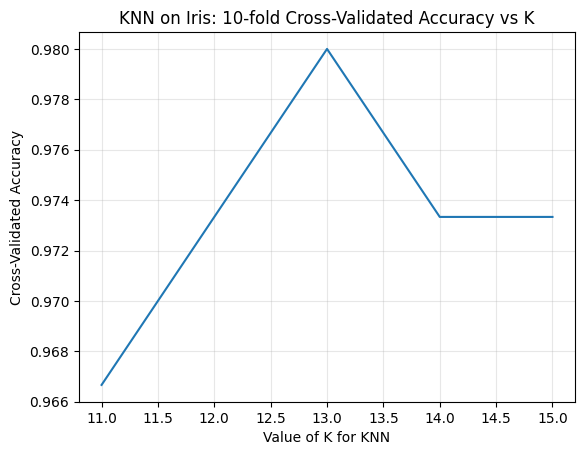

In [51]:
cross_val_acc_graph(11, 16)


### III. GridSearchCV to confirm the optimal K (10-fold CV)

In [52]:
k_values = list(range(1, 31))
param_grid = {"n_neighbors": k_values}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [53]:
print("Best params (GridSearchCV):", grid.best_params_)
print("Best mean CV accuracy (GridSearchCV):", grid.best_score_)

Best params (GridSearchCV): {'n_neighbors': 13}
Best mean CV accuracy (GridSearchCV): 0.9800000000000001


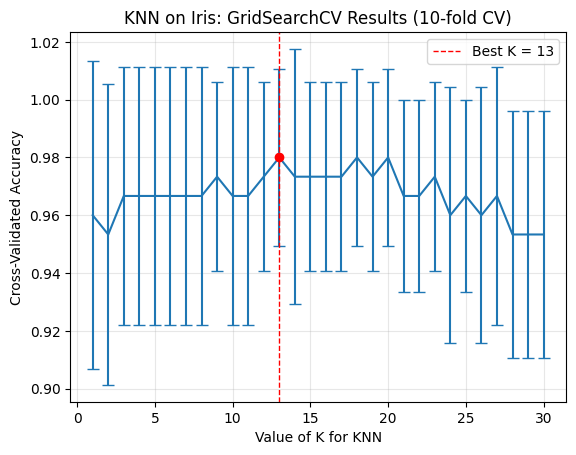

In [54]:
results = grid.cv_results_

mean_test = np.array(results["mean_test_score"])
std_test = np.array(results["std_test_score"])

# param values come back as objects; convert to int
ks = np.array([int(k) for k in results["param_n_neighbors"]])

order = np.argsort(ks)
ks = ks[order]
mean_test = mean_test[order]
std_test = std_test[order]

best_k = grid.best_params_["n_neighbors"]
y_best = mean_test[ks == best_k][0]

plt.figure()
plt.errorbar(ks, mean_test, yerr=std_test, capsize=4)
plt.scatter([best_k], [y_best], color="red", zorder=3)
plt.axvline(best_k, linestyle="--", linewidth=1, color="red", label=f"Best K = {best_k}")
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN on Iris: GridSearchCV Results (10-fold CV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()